In [1]:
!pip install -q opendatasets huggingface_hub monai scikit-learn pandas matplotlib seaborn

import json
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from torch.utils.data import Dataset as TorchDataset, DataLoader
from monai.transforms import Compose, ScaleIntensityd, Resized, ToTensord
from huggingface_hub import hf_hub_download
import opendatasets as od

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. إنشاء ملف الاعتمادات برمجياً للتحميل التلقائي
kaggle_credentials = {
    "username": "talalsvu",  
    "key": "KGAT_77406ef24de5abf5ed61ae789e0760ef"      
}
with open('kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

# تحميل البيانات بصمت
dataset_url = "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000"
print("جاري تحميل بيانات HAM10000 برمجياً...")
od.download(dataset_url, data_dir='./')

# 2. ربط المسارات وتقسيم البيانات لاستخراج بيانات الاختبار
base_dir = './skin-cancer-mnist-ham10000'
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x 
                     for x in glob.glob(os.path.join(base_dir, '*', '*.jpg'))}

df = pd.read_csv(os.path.join(base_dir, 'HAM10000_metadata.csv'))
df['path'] = df['image_id'].map(imageid_path_dict)
df['label_idx'] = pd.Categorical(df['dx']).codes
target_names = pd.Categorical(df['dx']).categories.tolist()

# نفس التقسيم الدقيق لضمان اختبار النظام على نفس الصور تماماً
_, dummy_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_idx'])
_, test_df = train_test_split(dummy_df, test_size=0.5, random_state=42, stratify=dummy_df['label_idx'])

# 3. الصنف الوسيط
class LocalSkinDataset(TorchDataset):
    def __init__(self, dataframe, transforms=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'path']
        label = self.dataframe.loc[idx, 'label_idx']
        
        img = Image.open(img_path).convert('RGB')
        img = np.array(img, dtype=np.float32)
        img = np.transpose(img, (2, 0, 1))
        
        data_dict = {"image": img, "label": np.array(label, dtype=np.int64)}
        if self.transforms:
            data_dict = self.transforms(data_dict)
        return data_dict

# 4. تجهيز Test Loader
test_transforms = Compose([
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    ToTensord(keys=["image", "label"])
])

test_ds = LocalSkinDataset(test_df, transforms=test_transforms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"تم تجهيز بيانات الاختبار. عدد الصور: {len(test_df)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.9 MB/s eta 0:00:0000:0100:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-16 19:24:12.116968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773689052.332948      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773689052.393233      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773689052.890960      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773689052.891008      55 computation_placer.cc:1

Using device: cuda
جاري تحميل بيانات HAM10000 برمجياً...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [00:25<00:00, 219MB/s] 



تم تجهيز بيانات الاختبار. عدد الصور: 1002


In [2]:
repo_id = "talalsvu/skin-cancer-base-models"
num_classes = 7

print("جاري تحميل الأوزان المتوازنة (Balanced Weights) من Hugging Face...")
resnet_path = hf_hub_download(repo_id=repo_id, filename="resnet50_skin_best_weights.pth")
densenet_path = hf_hub_download(repo_id=repo_id, filename="densenet121_skin_best_weights.pth")
efficientnet_path = hf_hub_download(repo_id=repo_id, filename="efficientnet_b0_skin_best_weights.pth")

# 1. ResNet-50
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50.load_state_dict(torch.load(resnet_path, map_location=device))
resnet50 = resnet50.to(device).eval()

# 2. DenseNet-121
densenet121 = models.densenet121(weights=None)
densenet121.classifier = nn.Linear(densenet121.classifier.in_features, num_classes)
densenet121.load_state_dict(torch.load(densenet_path, map_location=device))
densenet121 = densenet121.to(device).eval()

# 3. EfficientNet-B0
efficientnet_b0 = models.efficientnet_b0(weights=None)
efficientnet_b0.classifier[1] = nn.Linear(efficientnet_b0.classifier[1].in_features, num_classes)
efficientnet_b0.load_state_dict(torch.load(efficientnet_path, map_location=device))
efficientnet_b0 = efficientnet_b0.to(device).eval()

print("تم بناء النماذج الثلاثة وتحميل أوزانها الجاهزة بنجاح!")

جاري تحميل الأوزان من Hugging Face...


resnet50_skin_best_weights.pth:   0%|          | 0.00/94.4M [00:00<?, ?B/s]

densenet121_skin_best_weights.pth:   0%|          | 0.00/28.5M [00:00<?, ?B/s]

efficientnet_b0_skin_best_weights.pth:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

تم بناء النماذج الثلاثة وتحميل أوزانها الجاهزة بنجاح!


In [3]:
class EntropyDynamicEnsemble(nn.Module):
    """
    نظام هجين تكيفي (Dynamic Ensemble) يعتمد على الإنتروبيا (Entropy).
    يقوم بحساب الشك (Uncertainty) لكل نموذج لكل صورة بشكل مستقل، 
    ويعطي الوزن الأكبر للنموذج الأكثر ثقة (الأقل إنتروبيا).
    """
    def __init__(self, model1, model2, model3):
        super(EntropyDynamicEnsemble, self).__init__()
        self.model1 = model1
        self.model2 = model2
        self.model3 = model3
        
        # تجميد الأوزان لأن النماذج مدربة مسبقاً
        for param in self.parameters():
            param.requires_grad = False

    def compute_entropy(self, probs):
        # حساب الإنتروبيا: -sum(p * log(p))
        entropy = -torch.sum(probs * torch.log(probs + 1e-6), dim=1)
        return entropy

    def forward(self, x):
        # 1. استخراج المخرجات الخام
        logits1 = self.model1(x)
        logits2 = self.model2(x)
        logits3 = self.model3(x)

        # 2. تحويلها لاحتمالات
        probs1 = F.softmax(logits1, dim=1)
        probs2 = F.softmax(logits2, dim=1)
        probs3 = F.softmax(logits3, dim=1)

        # 3. حساب الإنتروبيا لكل نموذج
        ent1 = self.compute_entropy(probs1)
        ent2 = self.compute_entropy(probs2)
        ent3 = self.compute_entropy(probs3)

        # 4. حساب الأوزان التكيفية باستخدام Softmax على القيم السالبة للإنتروبيا
        # (الإنتروبيا الأقل ستحصل على أعلى وزن)
        entropies = torch.stack([ent1, ent2, ent3], dim=1)
        weights = F.softmax(-entropies, dim=1)

        # فصل الأوزان لمطابقة أبعاد مصفوفات الاحتمالات
        w1 = weights[:, 0].unsqueeze(1)
        w2 = weights[:, 1].unsqueeze(1)
        w3 = weights[:, 2].unsqueeze(1)

        # 5. الدمج الديناميكي النهائي
        dynamic_probs = (w1 * probs1) + (w2 * probs2) + (w3 * probs3)

        return dynamic_probs

# بناء النموذج الهجين
hybrid_model = EntropyDynamicEnsemble(resnet50, densenet121, efficientnet_b0).to(device)
hybrid_model.eval()

print("تم بناء خوارزمية النظام الهجين التكيفي بنجاح!")

تم تعريف خوارزمية التجميع الديناميكي بنجاح!


جاري تقييم النظام الهجين (Dynamic Ensemble) لـ 7 أمراض جلدية...

--- تقرير تصنيف النظام الهجين (Dynamic Ensemble) ---
              precision    recall  f1-score   support

       akiec       0.66      0.59      0.62        32
         bcc       0.84      0.90      0.87        52
         bkl       0.78      0.79      0.78       110
          df       0.90      0.82      0.86        11
         mel       0.89      0.48      0.62       112
          nv       0.92      0.98      0.95       671
        vasc       0.87      0.93      0.90        14

    accuracy                           0.89      1002
   macro avg       0.83      0.79      0.80      1002
weighted avg       0.88      0.89      0.88      1002

Multi-Class ROC-AUC Score: 0.9822



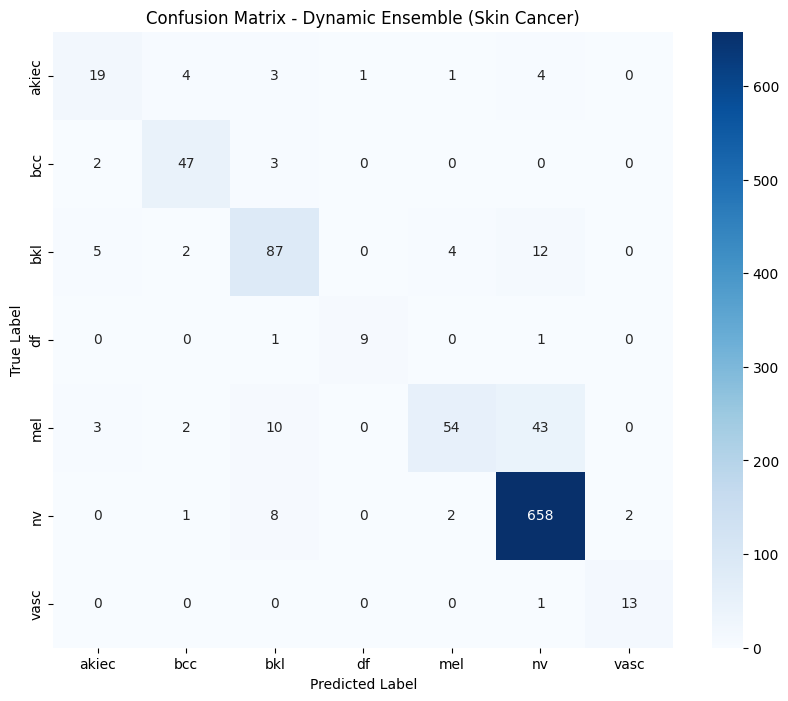

In [4]:
true_labels = []
ensemble_pred_labels = []
ensemble_pred_probs = [] 

print("جاري تقييم النظام الهجين (Dynamic Ensemble) لـ 7 أمراض جلدية...")
with torch.no_grad():
    for batch in test_loader:
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        # تمرير الصور مباشرة للنظام الهجين الذي سيتولى توزيع الأوزان داخلياً
        final_probs = hybrid_model(inputs)
        _, preds = torch.max(final_probs, 1)
        
        true_labels.extend(labels.cpu().numpy())
        ensemble_pred_labels.extend(preds.cpu().numpy())
        ensemble_pred_probs.extend(final_probs.cpu().numpy()) 

print("\n--- تقرير تصنيف النظام الهجين الديناميكي (Entropy-Based) ---")
print(classification_report(true_labels, ensemble_pred_labels, target_names=target_names))

# ROC-AUC للـ 7 فئات (One-vs-Rest)
roc_auc = roc_auc_score(true_labels, ensemble_pred_probs, multi_class='ovr')
print(f"Multi-Class ROC-AUC Score: {roc_auc:.4f}\n")

# رسم مصفوفة الارتباك
cm = confusion_matrix(true_labels, ensemble_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Dynamic Ensemble (Skin Cancer)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

جاري تقييم النظام باستخدام التجميع الثابت (Average Ensembling) للمقارنة...

--- تقرير تصنيف التجميع الثابت (Static Average Ensemble) ---
              precision    recall  f1-score   support

       akiec       0.68      0.59      0.63        32
         bcc       0.86      0.85      0.85        52
         bkl       0.78      0.83      0.81       110
          df       0.90      0.82      0.86        11
         mel       0.87      0.49      0.63       112
          nv       0.91      0.98      0.94       671
        vasc       0.93      0.93      0.93        14

    accuracy                           0.89      1002
   macro avg       0.85      0.78      0.81      1002
weighted avg       0.88      0.89      0.88      1002

Static Ensemble ROC-AUC Score: 0.9839



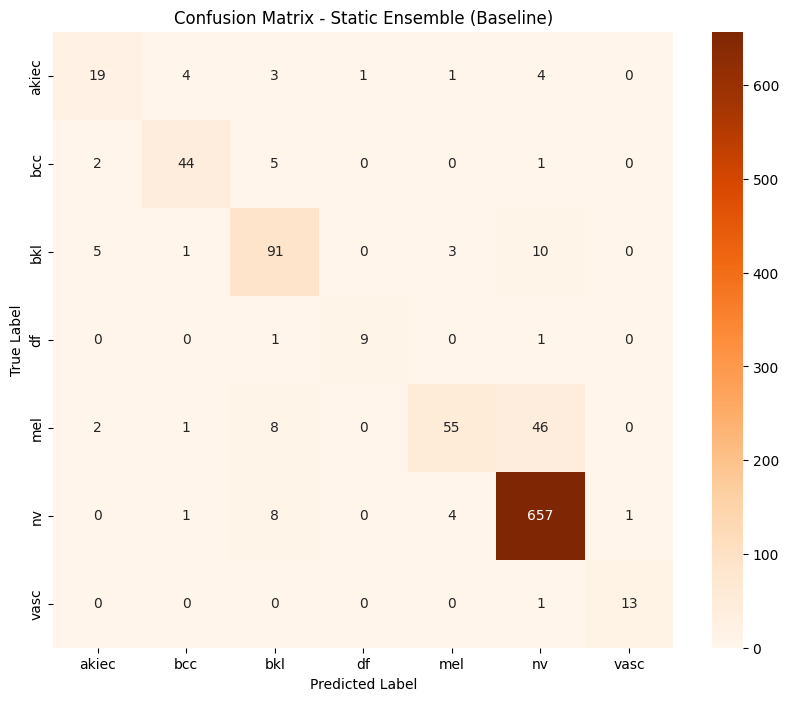

In [5]:
print("جاري تقييم النظام باستخدام التجميع الثابت (Average Ensembling) للمقارنة...")

static_pred_labels = []
static_pred_probs = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        # استخراج التوقعات من النماذج الثلاثة
        probs1 = torch.softmax(resnet50(inputs), dim=1)
        probs2 = torch.softmax(densenet121(inputs), dim=1)
        probs3 = torch.softmax(efficientnet_b0(inputs), dim=1)
        
        # التجميع الثابت (أخذ المتوسط الحسابي بالتساوي 33.3% لكل نموذج بغض النظر عن ثقته)
        avg_probs = (probs1 + probs2 + probs3) / 3.0
        
        _, preds = torch.max(avg_probs, 1)
        
        static_pred_labels.extend(preds.cpu().numpy())
        static_pred_probs.extend(avg_probs.cpu().numpy())

print("\n--- تقرير تصنيف التجميع الثابت (Static Average Ensemble) ---")
print(classification_report(true_labels, static_pred_labels, target_names=target_names))

# حساب ROC-AUC للتجميع الثابت
roc_auc_static = roc_auc_score(true_labels, static_pred_probs, multi_class='ovr')
print(f"Static Ensemble ROC-AUC Score: {roc_auc_static:.4f}\n")

# رسم مصفوفة الارتباك للتجميع الثابت
cm_static = confusion_matrix(true_labels, static_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_static, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Static Ensemble (Baseline)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

جاري توليد الخريطة الحرارية (Grad-CAM) لقابلية التفسير...


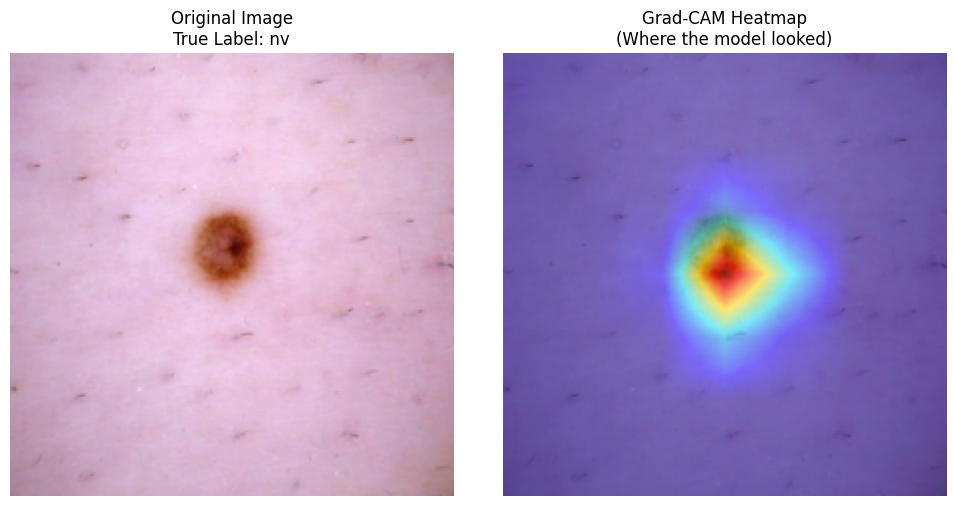

In [7]:
# تثبيت مكتبة Grad-CAM
!pip install -q grad-cam

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("جاري توليد الخريطة الحرارية (Grad-CAM) لقابلية التفسير (Explainability)...")

# 1. جلب صورة واحدة من بيانات الاختبار
model_explain = resnet50.eval()

# ==================== الحل الجوهري ====================
# إعادة تفعيل التدرجات للنموذج لأن خوارزمية Grad-CAM تحتاجها رياضياً
for param in model_explain.parameters():
    param.requires_grad = True
# ======================================================

sample_batch = next(iter(test_loader))
input_tensor = sample_batch["image"][0].unsqueeze(0).to(device)
true_label = sample_batch["label"][0].item()

# 2. تحضير الصورة للعرض البصري
img_show = input_tensor.squeeze().cpu().numpy()
img_show = np.transpose(img_show, (1, 2, 0))
img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

# 3. إعداد Grad-CAM لاستهداف الطبقة الالتفافية الأخيرة في ResNet
target_layers = [model_explain.layer4[-1]]
cam = GradCAM(model=model_explain, target_layers=target_layers)

# نطلب من الأداة تفسير الفئة الفعلية
targets = [ClassifierOutputTarget(true_label)]

# 4. توليد الخريطة الحرارية
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

# دمج الخريطة الحرارية مع الصورة الأصلية لإظهار مناطق تركيز النموذج
visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)

# 5. رسم النتيجة
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_show)
axes[0].set_title(f"Original Image\nTrue Label: {target_names[true_label]}")
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM Heatmap\n(Where the model looked)")
axes[1].axis('off')

plt.tight_layout()
plt.show()